In [ ]:


%pip install ipympl==0.9.3



  Using cached ipympl-0.9.3-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached ipython_genutils-0.2.0-py2.py3-none-any.whl.metadata (755 bytes)
Using cached ipympl-0.9.3-py2.py3-none-any.whl (511 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.8/831.8 kB 23.6 MB/s  0:00:00
Using cached ipython_genutils-0.2.0-py2.py3-none-any.whl (26 kB)
  Attempting uninstall: ipython
    Found existing installation: ipython 9.11.0
    Uninstalling ipython-9.11.0:
      Successfully uninstalled ipython-9.11.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipympl]2m2/3 [ipympl]]
Note: you may need to restart the kernel to use updated packages.


# Interferometry
## SAR Image
Single image is 2D 
- Azimuth coordinate (from absolute time)  corresponds to a horizontal coordinate on Earth
- Range coordinate (from return time) corresponds to a mixed horizontal/vertical coordinate

<div style="display: flex; gap: 20px;">
    <img src="../../figures/amplitude.png" style="width: 50%;">
    <img src="../../figures/phase.png" style="width: 50%;">
</div>

## SAR SLC observations

SLC: Single-Look Complex data
- Single-look: no averageing, finest spatial resolution
- Complex: both real and imaginary (In-Phase and quadrature phase)

A given pixel in a SAR image is a complex number where both amplitude and phase have a physical interpretable origin.


$$
y_1 = \underbrace{|y_1|}_{\text{Amplitude}} \exp(j\underbrace{\psi_1}_{\text{Phase}})
$$


**Amplitude** corresponds to the amount of radiated energy reflected back to the sensor and so shows up as the brightness of the pixel. The **phase** component of the pixel corresponds to the travel time of the received radar pulse and thus a function of distance of the target to the antenna.



The Phase components are represented as:

$$
\underline{\psi} = \psi_{\text{geom}}+ \psi_{\text{scat}}+\psi_{\text{atmo}}+\underline{\psi}_{\text{noise}}
$$

This phase combination of several phase components results in what is essentially a random number uniformly distributed on the interval $[-\pi, \pi)$.

The most important components here are the geometric phase $\psi_{\text{geom}}$ and the scattering phase $\psi_{\text{scat}}$

The observed value of a resolution cell in a SAR image is the sum of all the backscattered energy of the objects within that cell, called elementary scatterers. Certain objects will reflect a radar pulse back to the sensor more effectively due to their material properties, shape, size, and orientation. Different configurations of elementary scatterers will result in different observed behaviors. These scatterers can be categorized into groups according to their spatial and temporal characteristics.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets, interact, HBox, VBox
from IPython.display import display

A = 1.0  # fixed

def make_scatterers(N, seed):
    rng = np.random.default_rng(seed)
    amp = A * np.ones(N)
    pha = rng.uniform(-np.pi, np.pi, N)
    I = amp * np.cos(pha)
    Q = amp * np.sin(pha)
    colors = rng.uniform(0.1, 0.85, (N, 3))
    return I, Q, colors

def draw_scatterers(N, seed):
    import numpy as np                    # <-- add these two lines
    import matplotlib.pyplot as plt       # <-- at the top of the function
    I, Q, colors = make_scatterers(N, seed)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
    fig.subplots_adjust(wspace=0.3)

    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(0, color='gray', lw=0.5)
    ax1.axvline(0, color='gray', lw=0.5)
    for i in range(N):
        ax1.annotate("", xy=(I[i], Q[i]), xytext=(0, 0),
                     arrowprops=dict(arrowstyle="-|>", color=colors[i],
                                     lw=2, mutation_scale=12))
    lim = A * 1.25
    ax1.set_xlim(-lim, lim)
    ax1.set_ylim(-lim, lim)
    ax1.set_title(f'Individual scatterers (N={N})', fontsize=11)
    ax1.set_xlabel('I')
    ax1.set_ylabel('Q')

    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(0, color='gray', lw=0.5)
    ax2.axvline(0, color='gray', lw=0.5)

    si, sq = 0.0, 0.0
    for i in range(N):
        ax2.annotate("", xy=(si + I[i], sq + Q[i]), xytext=(si, sq),
                     arrowprops=dict(arrowstyle="-|>", color=colors[i],
                                     lw=2, mutation_scale=12))
        si += I[i]
        sq += Q[i]

    ax2.annotate("", xy=(si, sq), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", color='red',
                                 lw=3, mutation_scale=18))

    all_x = np.cumsum(np.concatenate([[0], I]))
    all_y = np.cumsum(np.concatenate([[0], Q]))
    margin = max(np.max(np.abs(all_x)), np.max(np.abs(all_y)), 0.5) * 1.2
    ax2.set_xlim(-margin, margin)
    ax2.set_ylim(-margin, margin)
    resultant = np.sqrt(si**2 + sq**2)
    ax2.set_title(f'Vector sum  |Amplitude resultant| = {resultant:.2f}', fontsize=11)
    ax2.set_xlabel('I')
    ax2.set_ylabel('Q')

    plt.show()

# hidden seed slider — registered with interact so widget state saves into notebook
seed_widget = widgets.IntSlider(value=0, min=0, max=1000, step=1)
seed_widget.layout.display = 'none'

resample_btn = widgets.Button(description='Resample', button_style='primary', icon='refresh')

def on_resample(btn):
    seed_widget.value += 1          # triggers interact to redraw

resample_btn.on_click(on_resample)

# show button above the interact output
display(resample_btn)

interact(draw_scatterers,
         N=widgets.IntSlider(value=10, min=1, max=20, step=1, description='N:'),
         seed=seed_widget)

Button(button_style='primary', description='Resample', icon='refresh', style=ButtonStyle())

interactive(children=(IntSlider(value=10, description='N:', max=20, min=1), IntSlider(value=0, description='se…

<function __main__.draw_scatterers(N, seed)>

### Point Scatterers

Resolution cells containing an object with a high radar cross-section (RCS) will be dominated by the reflections from that object. As a result, the behavior of the entire resolution cell can be localized to the point where that object is located, with all other elementary scatterers acting as clutter. Such a scatterer configuration is called a point scatterer (PS)
This type of analysis is called point scatterer interferometry (PSI)

```{figure} ../../figures/ps_scatterer.png
---
height: 300px
name: psi

---
```


### Distributed Scatterers

```{figure} ../../figures/ds_scatterer.png
---
height: 300px
name: dsi

---
```

```{figure} ../../figures/phase_diff.png
---
height: 300px
name: phase difference

---
```

## Interferometric phase observation

To get geometric information a combination of multiple coherent SAR acquisitions of the same scene need to be used.  The term *coherent* refers to the phases of the SAR acquisitions that are preserved, so that a coherent combination of two SAR image pixels can be the interference os the two samples wave returns of a given target. The coherent combination of two SAR phase images is called an interferogram, and the phase difference between two SAR pixels is called the interferometric phase. 

In order for the interferometric phase to contain any useful geometric information, there needs to be a difference between the two SAR images that are combined, either spatial or temporal. This difference is called the interferometric baseline, and the choice of this baseline will affect the type of information that is contained within the interferometric phase.

Using the interferometric configuration sketched in fig we derive the physical and the geometrical relationships between the two phase observations to obtain topographic height and surface deformation estimates.


$$
y_1 = |y_1|exp(j\psi_1)
$$
$$
y_2 = |y_2|exp(j\psi_2)
$$
$$
\mu=y_1y_2^*= |y_1||y_2|\exp{(j \psi_1-\psi_2)}
$$



$$
\frac{2R_1}{\lambda}= \frac{\psi_1}{2\pi}
$$

$$
\psi_1 = -\frac{4\pi}{\lambda}R_1
$$
$$
\psi_2 = -\frac{4\pi}{\lambda}R_2
$$

Interferometric phase (for given pixel $p$):

$$
\phi_p = \psi_{1p}-\psi_{2p}= - \frac{4\pi(R_1-R_2)}{\lambda}= - \frac{4\pi\Delta R}{\lambda}
$$

$$
\underline{\phi_p} = \phi_{\text{geom}}+ \phi_{\text{scat}}+\phi_{\text{atmo}}+\underline{\phi}_{\text{noise}}
$$

The individual components are the the phase contributions due to the differences:
- $\phi_{\text{geom}}$ in geometry
- $\phi_{\text{scat}}$ in scattering
- $\phi_{\text{atmo}}$ in atmosphere 
- $\underline{\phi}_{\text{noise}}$ is the sum of the noise in both pixels $p$






### Coherence

In [ ]:
from ipywidgets import widgets, HBox, VBox, Output, interact
from IPython.display import display

N = 10   # fixed
A = 1.0  # fixed

def make_acquisitions(gamma, seed):
    rng     = np.random.default_rng(seed)
    amps    = A*np.ones(N)
    phases1 = rng.uniform(-np.pi, np.pi, N)
    colors  = rng.uniform(0.1, 0.85, (N, 3))
    noise   = rng.uniform(-np.pi, np.pi, N)
    phases2 = phases1 + (1 - gamma) * noise
    vecs1   = np.stack([amps * np.cos(phases1), amps * np.sin(phases1)], axis=1)
    vecs2   = np.stack([amps * np.cos(phases2), amps * np.sin(phases2)], axis=1)
    return vecs1, vecs2, colors

def draw_chain(ax, vecs, colors, resultant_color, extent):
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    si, sq = 0.0, 0.0
    for v, col in zip(vecs, colors):
        ax.annotate("", xy=(si + v[0], sq + v[1]), xytext=(si, sq),
                    arrowprops=dict(arrowstyle="-|>", color=col,
                                   lw=1.8, mutation_scale=12))
        si += v[0]; sq += v[1]
    ax.annotate("", xy=(si, sq), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=resultant_color,
                               lw=3.5, mutation_scale=18))
    ax.set_xlim(-extent, extent)
    ax.set_ylim(-extent, extent)
    return si, sq

def draw(gamma, seed):
    vecs1, vecs2, colors = make_acquisitions(gamma, seed)

    s1I, s1Q = vecs1[:, 0].sum(), vecs1[:, 1].sum()
    s2I, s2Q = vecs2[:, 0].sum(), vecs2[:, 1].sum()
    dI,  dQ  = s2I - s1I, s2Q - s1Q

    all_coords = np.abs(np.concatenate([
        np.cumsum(np.concatenate([[0], vecs1[:, 0]])),
        np.cumsum(np.concatenate([[0], vecs1[:, 1]])),
        np.cumsum(np.concatenate([[0], vecs2[:, 0]])),
        np.cumsum(np.concatenate([[0], vecs2[:, 1]])),
    ]))
    extent12 = max(all_coords.max(), 0.5) * 1.25

    r1       = np.sqrt(s1I**2 + s1Q**2)
    r2       = np.sqrt(s2I**2 + s2Q**2)
    ph1      = np.degrees(np.arctan2(s1Q, s1I))
    ph2      = np.degrees(np.arctan2(s2Q, s2I))
    diff_mag = np.sqrt(dI**2 + dQ**2)
    dph      = ph2 - ph1
    if dph >  180: dph -= 360
    if dph < -180: dph += 360
    extent3  = max(r1, r2, diff_mag, 0.5) * 1.35

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle(f'Coherence  γ = {gamma:.2f}', fontsize=13, y=1.01)
    fig.subplots_adjust(wspace=0.4)

    draw_chain(axes[0], vecs1, colors, '#1a7fc1', extent12)
    axes[0].set_title(f'Acquisition 1\n|Y₁| = {r1:.2f}   φ₁ = {ph1:.1f}°', fontsize=11)
    axes[0].set_xlabel('I'); axes[0].set_ylabel('Q')

    draw_chain(axes[1], vecs2, colors, '#c17a1a', extent12)
    axes[1].set_title(f'Acquisition 2\n|Y₂| = {r2:.2f}   φ₂ = {ph2:.1f}°', fontsize=11)
    axes[1].set_xlabel('I'); axes[1].set_ylabel('Q')

    axes[2].set_aspect('equal')
    axes[2].grid(True, alpha=0.2)
    axes[2].axhline(0, color='gray', lw=0.5)
    axes[2].axvline(0, color='gray', lw=0.5)
    axes[2].annotate("", xy=(s1I, s1Q), xytext=(0, 0),
                     arrowprops=dict(arrowstyle="-|>", color='#1a7fc1',
                                    lw=2.5, mutation_scale=14, alpha=0.3))
    axes[2].annotate("", xy=(s2I, s2Q), xytext=(0, 0),
                     arrowprops=dict(arrowstyle="-|>", color='#c17a1a',
                                    lw=2.5, mutation_scale=14, alpha=0.3))
    axes[2].annotate("", xy=(s2I, s2Q), xytext=(s1I, s1Q),
                     arrowprops=dict(arrowstyle="-|>", color='#a32d2d',
                                    lw=3.5, mutation_scale=18))
    axes[2].set_xlim(-extent3, extent3)
    axes[2].set_ylim(-extent3, extent3)
    axes[2].set_title(f'Difference  (Y₂ − Y₁)\n|ΔY| = {diff_mag:.2f}   Δφ = {dph:.1f}°', fontsize=11)
    axes[2].set_xlabel('I'); axes[2].set_ylabel('Q')

    plt.show()

# ── Widgets ───────────────────────────────────────────────────────────────────
gamma_slider = widgets.FloatSlider(value=0.8, min=0.0, max=1.0, step=0.01,
                                   description='γ (coherence):',
                                   style={'description_width': 'initial'},
                                   layout=widgets.Layout(width='400px'),
                                   readout_format='.2f')
resample_btn = widgets.Button(description='Resample', button_style='primary', icon='refresh')
out          = Output()

state = {"seed": 0}

def refresh(gamma, seed):
    out.clear_output(wait=True)
    with out:
        draw(gamma, seed)

def on_resample(btn):
    state["seed"] += 1
    refresh(gamma_slider.value, state["seed"])

def on_gamma_change(change):
    refresh(change["new"], state["seed"])

resample_btn.on_click(on_resample)
gamma_slider.observe(on_gamma_change, names="value")

display(VBox([HBox([gamma_slider, resample_btn]), out]))
refresh(gamma_slider.value, state["seed"])


# from ipywidgets import widgets, interact
# N = 10   # fixed
# A = 1.0  # fixed

# def make_acquisitions(gamma, seed):
#     rng     = np.random.default_rng(seed)
#     amps    = A*np.ones(N)  # rng.uniform(0, A, N)
#     phases1 = rng.uniform(-np.pi, np.pi, N)
#     colors  = rng.uniform(0.1, 0.85, (N, 3))
#     noise   = rng.uniform(-np.pi, np.pi, N)
#     phases2 = phases1 + (1 - gamma) * noise
#     vecs1   = np.stack([amps * np.cos(phases1), amps * np.sin(phases1)], axis=1)
#     vecs2   = np.stack([amps * np.cos(phases2), amps * np.sin(phases2)], axis=1)
#     return vecs1, vecs2, colors

# def draw_chain(ax, vecs, colors, resultant_color, extent):
#     ax.set_aspect('equal')
#     ax.grid(True, alpha=0.2)
#     ax.axhline(0, color='gray', lw=0.5)
#     ax.axvline(0, color='gray', lw=0.5)
#     si, sq = 0.0, 0.0
#     for v, col in zip(vecs, colors):
#         ax.annotate("", xy=(si + v[0], sq + v[1]), xytext=(si, sq),
#                     arrowprops=dict(arrowstyle="-|>", color=col,
#                                    lw=1.8, mutation_scale=12))
#         si += v[0]; sq += v[1]
#     ax.annotate("", xy=(si, sq), xytext=(0, 0),
#                 arrowprops=dict(arrowstyle="-|>", color=resultant_color,
#                                lw=3.5, mutation_scale=18))
#     ax.set_xlim(-extent, extent)
#     ax.set_ylim(-extent, extent)
#     return si, sq

# def draw(gamma, seed):
#     vecs1, vecs2, colors = make_acquisitions(gamma, seed)

#     s1I, s1Q = vecs1[:, 0].sum(), vecs1[:, 1].sum()
#     s2I, s2Q = vecs2[:, 0].sum(), vecs2[:, 1].sum()
#     dI,  dQ  = s2I - s1I, s2Q - s1Q

#     all_coords = np.abs(np.concatenate([
#         np.cumsum(np.concatenate([[0], vecs1[:, 0]])),
#         np.cumsum(np.concatenate([[0], vecs1[:, 1]])),
#         np.cumsum(np.concatenate([[0], vecs2[:, 0]])),
#         np.cumsum(np.concatenate([[0], vecs2[:, 1]])),
#     ]))
#     extent12 = max(all_coords.max(), 0.5) * 1.25

#     r1       = np.sqrt(s1I**2 + s1Q**2)
#     r2       = np.sqrt(s2I**2 + s2Q**2)
#     ph1      = np.degrees(np.arctan2(s1Q, s1I))
#     ph2      = np.degrees(np.arctan2(s2Q, s2I))
#     diff_mag = np.sqrt(dI**2 + dQ**2)
#     dph      = ph2 - ph1
#     if dph >  180: dph -= 360
#     if dph < -180: dph += 360
#     extent3  = max(r1, r2, diff_mag, 0.5) * 1.35

#     fig, axes = plt.subplots(1, 3, figsize=(16, 6))
#     fig.suptitle(f'Coherence  γ = {gamma:.2f}', fontsize=13, y=1.01)
#     fig.subplots_adjust(wspace=0.4)

#     draw_chain(axes[0], vecs1, colors, '#1a7fc1', extent12)
#     axes[0].set_title(f'Acquisition 1\n|Y₁| = {r1:.2f}   φ₁ = {ph1:.1f}°', fontsize=11)
#     axes[0].set_xlabel('I'); axes[0].set_ylabel('Q')

#     draw_chain(axes[1], vecs2, colors, '#c17a1a', extent12)
#     axes[1].set_title(f'Acquisition 2\n|Y₂| = {r2:.2f}   φ₂ = {ph2:.1f}°', fontsize=11)
#     axes[1].set_xlabel('I'); axes[1].set_ylabel('Q')

#     axes[2].set_aspect('equal')
#     axes[2].grid(True, alpha=0.2)
#     axes[2].axhline(0, color='gray', lw=0.5)
#     axes[2].axvline(0, color='gray', lw=0.5)
#     axes[2].annotate("", xy=(s1I, s1Q), xytext=(0, 0),
#                      arrowprops=dict(arrowstyle="-|>", color='#1a7fc1',
#                                     lw=2.5, mutation_scale=14, alpha=0.3))
#     axes[2].annotate("", xy=(s2I, s2Q), xytext=(0, 0),
#                      arrowprops=dict(arrowstyle="-|>", color='#c17a1a',
#                                     lw=2.5, mutation_scale=14, alpha=0.3))
#     axes[2].annotate("", xy=(s2I, s2Q), xytext=(s1I, s1Q),
#                      arrowprops=dict(arrowstyle="-|>", color='#a32d2d',
#                                     lw=3.5, mutation_scale=18))
#     axes[2].set_xlim(-extent3, extent3)
#     axes[2].set_ylim(-extent3, extent3)
#     axes[2].set_title(f'Difference  (Y₂ − Y₁)\n|ΔY| = {diff_mag:.2f}   Δφ = {dph:.1f}°', fontsize=11)
#     axes[2].set_xlabel('I'); axes[2].set_ylabel('Q')

#     plt.show()

# interact(draw,
#          gamma=widgets.FloatSlider(value=0.8, min=0.0, max=1.0, step=0.01,
#                                    description='γ (coherence):',
#                                    style={'description_width': 'initial'},
#                                    layout=widgets.Layout(width='400px'),
#                                    readout_format='.2f'),
#          seed=widgets.IntSlider(value=0, min=0, max=100, step=1, description='Seed:'))

## Interferogram formation

Th interferogram is constructed by a point wise complex multiplication.

$$
y_1y_2^* = |y_1|\exp(j\psi_1)|y_2|\exp(-j\psi_2)= |y_1||y_2|\exp(j(\psi_1 - \psi_2))
$$


The interferometric phase $\phi_p$  is the difference between the two scattering components of a give pixel $P$, and is written as: 
$$
\phi_p= \psi_1 - \psi_2
$$

Thus the components of the interferometric phase are:

$$
\underline{\phi_p} = \phi_{\text{geom}}+ \phi_{\text{scat}}+\phi_{\text{atmo}}+\underline{\phi}_{\text{noise}}
$$


We are interested in the geometric phase which consists of 3 sub-components:

$$
\phi_{\text{geom}}= \phi_{\text{disp}}+\phi_{\text{ref}}+\underline{\phi}_{\text{topo}}
$$

- $\phi_{\text{disp}}$ is the displacement phase
- $\phi_{\text{ref}}$ is the reference phase
- $\phi_{\text{topo}}$ is the topographic phase

```{figure} ../../figures/interferometric_configuration.png
---
height: 300px
name: interf_config

---

```



### Topographic Phase

$$
\phi_p =  - \frac{4\pi\Delta R}{\lambda}
$$

$$
\partial \phi_p= -\frac{4 \pi}{\lambda}\partial \Delta R
$$

$$
\Delta R = B\sin(\theta-\alpha)
$$
$$
\partial \Delta R = B\cos(\theta^{\circ}-\alpha)\partial \theta
$$
initial value of $\theta^{\circ}$ is obtained for the reference surface
$$
\partial \phi_p = -\frac{4 \pi}{\lambda} B\cos(\theta^{\circ}-\alpha)\partial \theta
$$



$$
H_p =  -\frac{\lambda R_1 \sin\theta^{\circ} }{4 \pi B_{\perp}} \partial\phi_p
$$

With $B_{\perp}= B\cos(\theta^{\circ}-\alpha)$

### Reference Phase

$$
\phi_{ref}= \frac{4\pi}{\lambda}B\sin(\theta - \alpha) 
$$



### Displacement Phase

The phase contribution of the motion of the target between the two acquisitions is referred to as the *displacement phase*

$$
\phi_{disp}= \frac{-4\pi}{\lambda}\Delta_r
$$

With $\Delta_r$ being the line-of-sight deformation

**little note about terminology deterministic and stocastic terms**

## SLC phase $\psi_i$ 

Phasor $\underbar{P}_i$ single PS point $i$

$$
\underbar{P}_i= A_i \exp(i \underline{\psi}_i)
$$

With amplitude $A_i$ and SLC phase $\underline{\psi_i}$
The noise follows a circular Gaussian distribution represented as the noise of the real and imaginary components $\sigma_{Re_i}$ and $\sigma_{Im_i}$


The amplitude $A_i$ is computed with:

$$
\underline{A}_i= \sqrt{(Re_{\underline{P}_i})^2 + (Im_{\underline{P}_i})^2}
$$

The dispersion of the amplitude is the clutter $\sigma_{A_i}= \sigma_{Re_i}= \sigma_{Im_i}$ 

The SLC phase values can be computed using:

$$
\underline{\psi}_i= \arctan(\frac{Im_{\underline{P}_i}}{Re_{\underline{P}_i}})
$$

In [ ]:
#simulate single phasors
#simulate clutter
#simulate signal (signal-to-clutter ratio of 20dB)



## Single difference

We select coherent point scatters (PS). For a point scatterer $i$ we take the temporal single difference (SD) phase $\phi_i^{md}$. Here we compute the temporal differences by selecting a *mother* image $m$ to which the other images, the *daughters* $d$ are all relative to. We can denote this $\phi_i^{md}= \psi_i^d-\psi_i^{,}$ We are subtracting the mother from the daughters. This is done via a complex multiplication:

$$
\underline{P_i}^{md}= \underline{P}^d_i \cdot P^{m*}_i= \underline{A}_i^d A_i^m \exp(i(\underline{\psi}_i^d - \psi_i^m))

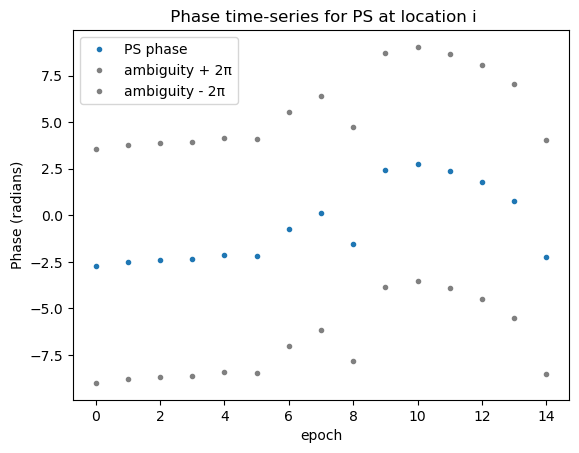

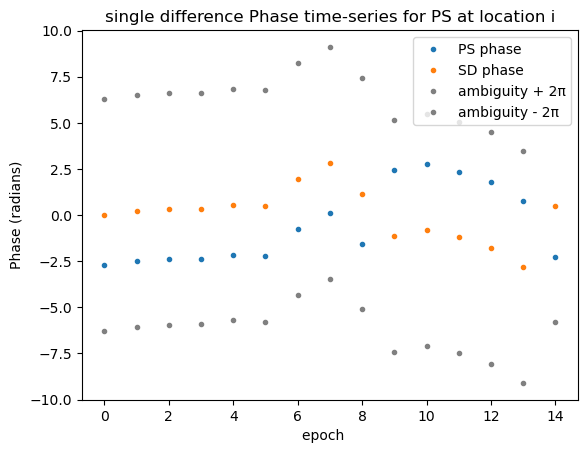

Single-difference phase at the mother epoch: -0.0


In [32]:
#Simulate a PS at location i, this is an array of complex values for each epoch

PS = np.array([-490.4617  -221.74728j, -451.1481  -336.14886j,
       -396.86014 -373.78778j, -351.754   -347.6464j ,
       -295.88983 -457.1554j , -383.81723 -516.31494j,
        460.75153 -424.69525j,  630.72186  +73.9702j ,
         11.978053-628.03064j, -375.4135  +328.4324j ,
       -543.174   +221.85329j, -389.77322 +392.23367j,
       -119.34835 +533.6919j ,  439.2838  +408.00806j,
       -402.63724 -498.39398j])


PS_phase = np.angle(PS) #take angle
PS_amplitude = np.abs(PS) #take amplitude


epochs = np.arange(15)

#also plot the phase timeseries shifted by 2*pi and -2*pi to show the ambiguity of the phase
plt.figure()
plt.plot(epochs, PS_phase, '.', label = 'PS phase', color = 'tab:blue')
plt.plot(epochs, PS_phase + 2*np.pi, '.', label = 'ambiguity + 2π', color = 'gray' )
plt.plot(epochs, PS_phase - 2*np.pi, '.', label = 'ambiguity - 2π', color = 'gray' )  
plt.ylabel('Phase (radians)')
plt.xlabel('epoch')
plt.title(' Phase time-series for PS at location i')  
plt.legend()
plt.show() 


# Define mother epoch and compute single-difference stack 

idx_mother_date = 0 #here i choose the first epoch as the mother epoch, but you can choose any other epoch as the mother epoch.

#subtract the complex values at the mother epoch from the complex values at all epochs to get the single-difference stack
sd_PS = PS * np.conj(PS[idx_mother_date])
sd_phi = np.angle(sd_PS)

#plot the original SLC ps phase timeseries for the same point for comparison
plt.plot(epochs, PS_phase, '.', label = 'PS phase', color = 'tab:blue')
plt.plot(epochs, sd_phi, '.', label = 'SD phase', color = 'tab:orange')
#also plot the phase timeseries shifted by 2*pi and -2*pi to show the ambiguity of the phase for the single-difference stack
plt.plot(epochs, sd_phi + 2*np.pi, '.', label = 'ambiguity + 2π', color = 'gray' )
plt.plot(epochs, sd_phi - 2*np.pi, '.', label = 'ambiguity - 2π', color = 'gray' )
plt.ylabel('Phase (radians)')
plt.xlabel('epoch   ')
plt.title('single difference Phase time-series for PS at location i')
plt.legend()
plt.show()


print('Single-difference phase at the mother epoch:', np.round(sd_phi[idx_mother_date], 2))







## Double-Difference Arc Phase

The temporal difference of one point does not provide meaningful information we also want to create a spatial difference.  So we observe the difference in phase not just in time but also between two points in space.
To get the useful information about the displacement phase, the other components need to be removed. we refer to two points in space as forming an *arc*. 

The double-differece arc phase of a point $\varphi_{ij}^{md}$ , i with respect to another point j, can be written as:

$$
\varphi_{ij}^{md} = \phi_{i}^{md}-\phi_{j}^{md}
$$

Point $m$ is called the reference point and because of this all InSAR derived displacements are relative to a referece point.
Therefore its important to select the reference point with care.
